In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd /Users/armandoroqueestrada/Proyecto_Proca/stability

/Users/armandoroqueestrada/Proyecto_Proca/Stability


In [3]:
import Modules.Background as bg
import numpy as np

import matplotlib.pyplot as plt
import Modules.Plot as cplot

In [4]:
cplot.general()

### Cargando perfiles

In [5]:
# Family_cte_polarization_LPn1 = np.load("/Users/armandoroqueestrada/Proyecto_Proca/Stability/background_data_profiles_lambda_n_case/Family_cte_polarization_LPn1.npy", allow_pickle=True)
Family_cte_polarization_LNn1 = np.load("/Users/armandoroqueestrada/Proyecto_Proca/Stability/background_data_profiles_lambda_n_case/Family_cte_polarization_LNn1.npy", allow_pickle=True)
Family_cte_polarization_LNn1_ext = np.load("/Users/armandoroqueestrada/Proyecto_Proca/Stability/background_data_profiles_lambda_n_case/Family_cte_polarization_LNn1_ext.npy", allow_pickle=True)

In [6]:
# len(Family_cte_polarization_LPn1)
len(Family_cte_polarization_LNn1)

103

(0.0, 15.0)

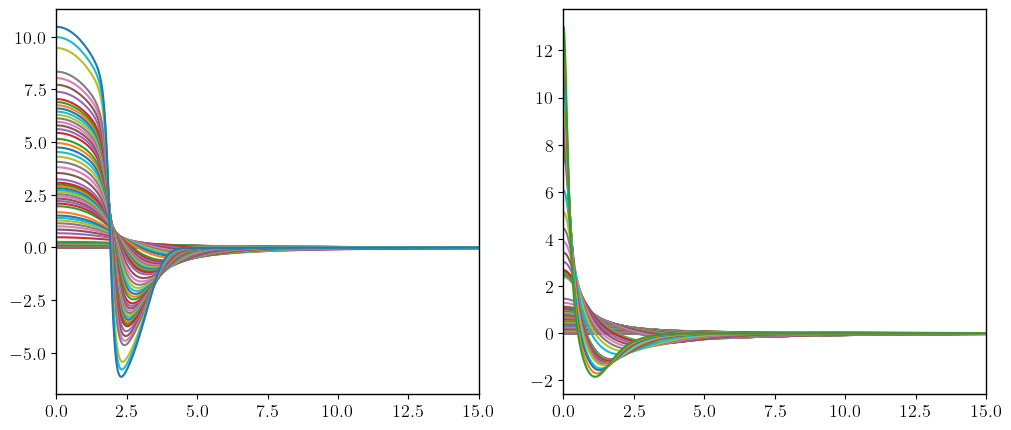

In [7]:
# [Ei, rDnew, sDnew, dsDnew, uDnew, duDnew]

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

for dat in Family_cte_polarization_LPn1:
    ax[0].plot(dat[1], dat[2], label=fr"$\sigma_{0}={dat[2][0]:.3f}$")

for dat in Family_cte_polarization_LNn1:
    ax[1].plot(dat[1], dat[2], label=fr"$\sigma_{0}={dat[2][0]:.3f}$")

ax[0].set_xlim(0, 15)
ax[1].set_xlim(0, 15)

### Stability 

In [7]:
import Modules.SpectralMeth as sp
from scipy.interpolate import interp1d

In [8]:
# n = 1
# s0 = Family_cte_polarization_LPn1
#s0M = Family_cte_polarization_LNn1
s0M_ext = Family_cte_polarization_LNn1_ext

In [12]:
lambdaValGeneral, dataExtraGeneral = [[], []], [[], []]
datFuncGeneral = [[], []]

polariz = 'linear'

Jval = [0, 1, 2, 3]
alp = 0.0
ln = [-1.] # 1., -1.
for cont0, conf in enumerate([s0M_ext]):  #s0M s0 54:61 55:61
    print('#' * 50)
    lamV = [ln[cont0], 0] # ln, ls
    for cont, s in enumerate(conf): 
        Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s
        print('==> ', sDnew[0])
        datFunc = [
            [interp1d(rDnew, sDnew)],
            [interp1d(rDnew, uDnew)],
        ]

        #if cont < 3:
        #    rMax = 8000
        #    Nptos = 850
        #elif cont < 15:
        #    rMax = 1500
        #    Nptos = 800
        #elif cont < 15:
        #    rMax = 750
        #    Nptos = 800
        #else:
        rMax = 450
        Nptos = 800
        # print(f"rMax = {rMax}, Nptos = {Nptos}")

        # Graphing
        #rad2 = np.linspace(0, rMax, 500000)
        #fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
        #               sharex=False, sharey=False,
        #               gridspec_kw=dict(hspace=0, wspace=.2))

        #ax[0].plot(rad2, np.abs(datFunc[0][0](rad2)))
        #ax[1].plot(rad2, Ei - datFunc[1][0](rad2))
        #ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
        #ax[0].set_xlim(0, rMax)
        #ax[0].set_yscale('log')    
        #plt.show()

        lambdaVal, dataExtra = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)
    
        for ind, [Jval_temp, data] in enumerate(dataExtra):
            rdis, eingVal, eigVect = data
            print('Jval = %d'%Jval_temp)
            ind = np.abs(np.real(eingVal)) >= 1e-08 # filtrando los autovalores reales
            print(eingVal[ind])

        # Save data
        datFuncGeneral[cont0].append(datFunc)
        lambdaValGeneral[cont0].append(lambdaVal)
        dataExtraGeneral[cont0].append(dataExtra)

##################################################
==>  4.01676111
Jval = 0: [####################] 100%
[ 4.28997244e-08+1.19041469e-05j -4.29004860e-08-1.19042164e-05j
 -2.38156796e+00+2.59861732e+00j  2.38156796e+00+2.59861732e+00j
  2.38156796e+00-2.59861732e+00j -2.38156796e+00-2.59861732e+00j]
Jval = 1
[ 0.22181767-3.44016588e-14j -0.22181767-5.07003579e-14j]
Jval = 2
[-0.43259017+9.36736722e-15j  0.43259017+9.69517484e-15j]
Jval = 3
[]
==>  4.15621647
Jval = 0: [####################] 100%
[ 1.01720232e-04+4.76172416e-09j -1.01720235e-04-5.24244440e-09j
  2.55278281e+00+2.69281959e+00j -2.55278281e+00+2.69281959e+00j
 -2.55278281e+00-2.69281959e+00j  2.55278281e+00-2.69281959e+00j]
Jval = 1
[ 0.2506524+7.18483300e-14j -0.2506524+6.95731649e-14j]
Jval = 2
[ 0.44957822-3.77065672e-14j -0.44957822-4.11233547e-14j]
Jval = 3
[]
==>  4.29567183
Jval = 0: [####################] 100%
[-2.67748869e-08-4.64036740e-05j  2.67761142e-08+4.64037158e-05j
  6.02889889e-02-4.19970579e-11j -6.0288

In [11]:
lamV

[1.0, 0]

In [13]:
data_real_save = []
for cont, dataExtra in enumerate(dataExtraGeneral[0]):
    temp = datFuncGeneral[0][cont]
    s0Dat = temp[0][0](0)
    dataJ = []
    for ind, [Jval_temp, data] in enumerate(dataExtra):
        rdis, eingVal, eigVect = data
        ind = np.abs(np.real(eingVal)) >= 1e-06 # filtrando los autovalores reales
        dataJ.append([Jval_temp, float(s0Dat), rdis if sum(ind)!=0 else [], eingVal[ind], eigVect[:, ind]])
    data_real_save.append(dataJ)

In [11]:
# data_real_save

In [14]:
np.save("Real_Eingevalues_cte_polarization_LNn1_ext", np.array(data_real_save, dtype=object))

In [13]:
# Plot

In [38]:
# Load the data
Real_Eingevalues_cte_polarization_LNn1 = np.load("stability_lambda_n_case/Polarization_constant/Real_Eingevalues_cte_polarization_LNn1.npy", allow_pickle=True)
#Real_Eingevalues_cte_polarization_LPn1 = np.load("stability_lambda_n_case/Polarization_constant/Real_Eingevalues_cte_polarization_LPn1.npy", allow_pickle=True)

In [39]:
Real_Eingevalues_cte_polarization_LPn1 =  np.load("Real_Eingevalues_cte_polarization_LPn1.npy", allow_pickle=True)
Real_Eingevalues_cte_polarization_LPn1 = np.reshape(Real_Eingevalues_cte_polarization_LPn1, (81, 4, 5))

Text(0, 0.5, '$\\lambda_{R}$')

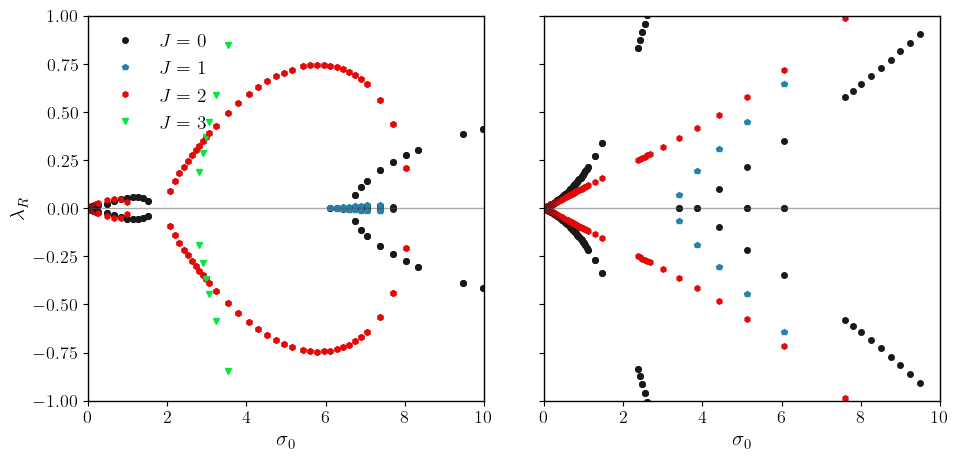

In [42]:
col = ['#1a1919', '#2681ab', "#e30909", "#05e73e"]
mark = ['o', 'p', 'h', 'v']

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(11, 5.), sharex=False, sharey=True,
                       gridspec_kw=dict(hspace=0, wspace=.15))

# [Jval_temp, s0, r, eingVal, eigVect]
dtemp = []
for cont, dataExtra in enumerate(Real_Eingevalues_cte_polarization_LPn1):
      for cond2, [Jval_temp, s0, _, eingVal, _] in enumerate(dataExtra):
            #if Jval_temp in [2, 3]:
            #      continue
            ind = np.abs(np.real(eingVal)) >= 9e-06
            y = eingVal[ind]
            x = [s0] * len(y)
            if cont == 0:
                  ax[0].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4, label=r'$J=%d$'%Jval_temp)
            else:
                  ax[0].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4)

            if y.size !=0:
                  dtemp.append([x, y])
#      dtemp = np.array(dtemp)
#      if dtemp.size !=0:
#            ax[0].plot(dtemp[:, 0], dtemp[:,1], ls='--', color=col[cond2])

      ax[0].legend(frameon=False, fontsize=14)
      #ax[0].vlines(x=1, ymin=-1, ymax=1, )

dtemp = []
for cont, dataExtra in enumerate(Real_Eingevalues_cte_polarization_LNn1):
      for cond2, [Jval_temp, s0, _, eingVal, _] in enumerate(dataExtra):
            #if Jval_temp in [2, 3]:
            #      continue
            ind = np.abs(np.real(eingVal)) >= 9e-06 # filtrando los autovalores reales
            y = eingVal[ind]
            x = [s0] * len(y)
            if cont == 0:
                  ax[1].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4, label=r'$J=%d$'%Jval_temp)
            else:
                  ax[1].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4)
            
            if y.size !=0 and cond2==0:
                  dtemp.append([x, y])

# ax[1].legend(frameon=False, fontsize=14)
dtemp = np.array(dtemp, dtype=object)
#if dtemp.size !=0:
#      ind = dtemp[:, 1]>0
#      ax[1].plot(dtemp[:, 0][ind], dtemp[:, 1][ind], ls='-', color=col[0], lw=1)
#      ax[1].plot(dtemp[:, 0][~ind], dtemp[:, 1][~ind], ls='-', color=col[0], lw=1)

#ax[1].vlines(x=1.0, ymin=-5, ymax=6, ls=':', lw=1.5, color=col[0])
#ax[1].text(x=0.7, y=0.42, s=r'$\sigma_0^{M^{\mathrm{max}}_{99}}\approx1.0$', color=col[0], rotation=90, fontsize=12)

for axes in ax:
    axes.set_xlim(0, 10)
    axes.set_ylim(-1., 1.)
    axes.set_xlabel(r'$\sigma_0$')

    axes.hlines(y=0, xmin=0, xmax=11.5, ls='-', lw=1, color='#55555e', alpha=0.5)

ax[0].set_ylabel(r'$\lambda_{R}$')
#ax[0].vlines(x=9.460393448801062, ymin=-5, ymax=6, ls=':', lw=1.5, color=col[0])
#ax[0].vlines(x=8.336591227271809, ymin=-5, ymax=6, ls=':', lw=1.5, color=col[0])


#ax[0].vlines(x=1.5117311258028474, ymin=-5, ymax=6, ls=':', lw=1.5, color=col[0])
#ax[0].vlines(x=1.6708004365129787, ymin=-5, ymax=6, ls=':', lw=1.5, color=col[0])
#ax[0].vlines(x=1.9533518964731258, ymin=-5, ymax=6, ls=':', lw=1.5, color=col[0])
#ax[0].vlines(x=2.080748598115769, ymin=-5, ymax=6, ls=':', lw=1.5, color=col[0])

#ax[0].text(x=0.15, y=1.8, s=r'one node')
#ax[0].text(x=0.15, y=-5.6, s=r'stationary (constant), with $\lambda_n= + 1$ and $\lambda_s=0$', fontsize='12')
#ax[1].text(x=0.15, y=-5.6, s=r'stationary (constant), with $\lambda_n= - 1$ and $\lambda_s=0$', fontsize='12')

In [ ]:
fig.savefig('stationary_cte_n.pdf', format='pdf', #metadata=None, # dpi='figure',
        pad_inches=0.1,
        facecolor='auto', edgecolor='auto',
        backend=None, dpi=1000, 
        bbox_inches='tight'# Plot will be occupy a maximum of available space # bbox_inches=None,
       )